In [1]:
import ast

In [3]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted-date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


c:\Users\xo16qyly\AppData\Local\anaconda3\envs\clean_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df_grouped = df.groupby('job_title_short').agg(
    job_count=('job_title_short','count'),
    median_yearly_salary=('salary_year_avg','median')
)
df_grouped

,job_count,median_yearly_salary
job_title_short,,
Business Analyst,49063,85000.0
Cloud Engineer,12331,90000.0
Data Analyst,196075,90000.0
Data Engineer,186241,125000.0
Data Scientist,172286,127500.0
Machine Learning Engineer,14080,106415.0
Senior Data Analyst,29216,111175.0
Senior Data Engineer,44563,147500.0
Senior Data Scientist,36957,155500.0


In [7]:
df_grouped = df_grouped.sort_values(by='job_count', ascending=False).head(10)

df_grouped

,job_count,median_yearly_salary
job_title_short,,
Data Analyst,196075,90000.0
Data Engineer,186241,125000.0
Data Scientist,172286,127500.0
Business Analyst,49063,85000.0
Software Engineer,44929,99150.0
Senior Data Engineer,44563,147500.0
Senior Data Scientist,36957,155500.0
Senior Data Analyst,29216,111175.0
Machine Learning Engineer,14080,106415.0


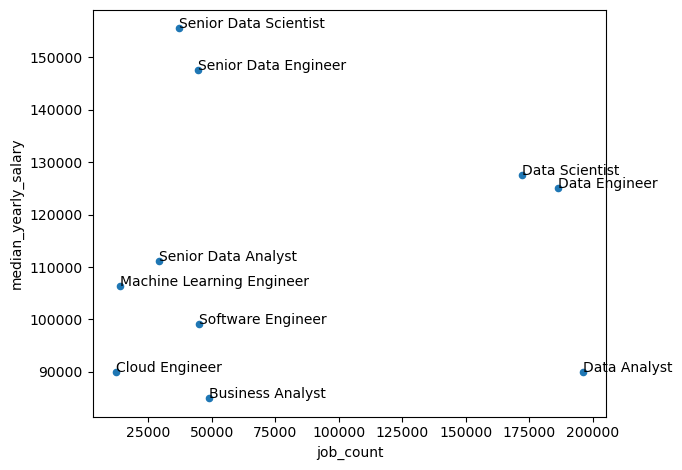

In [17]:
df_grouped.plot(kind='scatter', x='job_count', y='median_yearly_salary')
plt.tight_layout()

for i,txt in enumerate(df_grouped.index):
    plt.text(df_grouped['job_count'].iloc[i], df_grouped['median_yearly_salary'].iloc[i] , txt)


plt.show()
